# 🔎 Forensic Glass Identification — Step 3: Exploratory Data Analysis

**Project design step 3 of 5** (Research → Planning → **EDA** → Model building → Modularization)

When glass breaks at a crime scene, forensic scientists measure the fragment's **refractive index (RI)** and its
**oxide composition** (Na, Mg, Al, Si, K, Ca, Ba, Fe as weight-%) to work out *what kind of glass* it came from.
Our job is to predict that glass type from those 9 numbers.

**Questions this notebook answers**

1. Is the data clean? (missing values, duplicates, strange zeros)
2. How balanced are the classes?
3. What do the feature distributions look like, and do they need transforming?
4. Which features actually separate the glass types?
5. Which classes will be hard to tell apart?
6. Should outliers be removed?

Each section ends with a **Key insight** box, and the last section turns them into concrete modeling decisions.

| Feature | Meaning | | Type | Class |
|---|---|---|---|---|
| RI | refractive index | | 1 | Building windows, float processed |
| Na, Mg, Al, Si, K, Ca, Ba, Fe | oxide weight % | | 2 | Building windows, non-float |
| | | | 3 | Vehicle windows, float |
| | | | 5 | Containers |
| | | | 6 | Tableware |
| | | | 7 | Headlamps |

*(Type 4 — vehicle windows, non-float — is described in the dataset docs but has no samples.)*

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Find the project root (the folder containing `src/`) so imports work
# no matter where Jupyter was started from.
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "src").exists(), (
    "Open this notebook from inside the glass-forensics project folder (it needs the `src/` package).")
sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.precision", 3)
RANDOM_STATE = 42

from src.config import FEATURES, TARGET, CLASS_NAMES
from src.data_loader import load_data

# One fixed colour per glass type, reused in every plot
PALETTE = dict(zip(sorted(CLASS_NAMES), sns.color_palette("tab10", len(CLASS_NAMES))))
LABELS = {c: f"{c}: {n}" for c, n in CLASS_NAMES.items()}

## 1. Load the data and take a first look

In [2]:
df = load_data()          # downloads data/glass.csv automatically if it is missing
print("Shape:", df.shape)
df.head()

Shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.521,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.518,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.516,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.518,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.517,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


## 2. Data quality: missing values, duplicates, zeros

In [4]:
display(df[FEATURES].describe().T)
print("Missing values per column:\n", df.isnull().sum().to_string())
dups = df[df.duplicated(keep=False)]
print(f"\nExact duplicate rows: {df.duplicated().sum()}")
display(dups)

,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518,0.003,1.511,1.517,1.518,1.519,1.534
Na,214.0,13.408,0.817,10.730,12.908,13.300,13.825,17.380
Mg,214.0,2.685,1.442,0.000,2.115,3.480,3.600,4.490
Al,214.0,1.445,0.499,0.290,1.190,1.360,1.630,3.500
Si,214.0,72.651,0.775,69.810,72.280,72.790,73.088,75.410
K,214.0,0.497,0.652,0.000,0.122,0.555,0.610,6.210
Ca,214.0,8.957,1.423,5.430,8.240,8.600,9.172,16.190
Ba,214.0,0.175,0.497,0.000,0.000,0.000,0.000,3.150
Fe,214.0,0.057,0.097,0.000,0.000,0.000,0.100,0.510


Missing values per column:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0

Exact duplicate rows: 1


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
38,1.522,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1
39,1.522,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1


In [5]:
zeros = (df[FEATURES] == 0).sum().to_frame("n_zeros")
zeros["pct_of_rows"] = (100 * zeros["n_zeros"] / len(df)).round(1)
zeros.T

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
n_zeros,0.0,0.0,42.0,0.0,0.0,30.0,0.0,176.0,144.0
pct_of_rows,0.0,0.0,19.6,0.0,0.0,14.0,0.0,82.2,67.3


> **Key insight — data quality**
> * **No missing values**, so no imputation is needed.
> * There is **1 exact duplicate** (a class-1 sample appearing twice). If one copy landed in the training set and the other
>   in the test set, the model would be "tested" on something it had already memorised, which inflates scores. We will **drop it before splitting**.
> * Mg, K, Ba and Fe contain many **zeros** (Ba is zero in 176 of 214 rows, 82%). These are real measurements meaning
>   "this oxide was not detected / is absent", **not** missing data, so we must not impute them.

## 3. Target distribution (class balance)

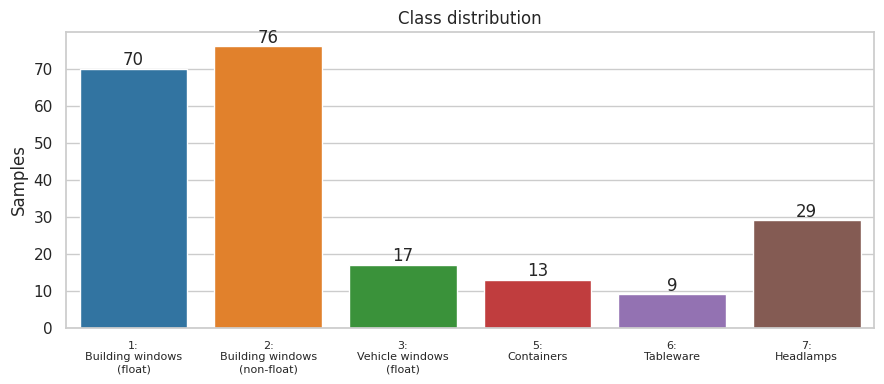

Imbalance ratio (largest / smallest class): 8.4 : 1
Accuracy of always guessing the majority class: 35.5%


In [6]:
counts = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=PALETTE, legend=False, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([LABELS[c].replace(": ", ":\n").replace(" (", "\n(") for c in counts.index], fontsize=8)
ax.set_ylabel("Samples"); ax.set_xlabel("")
ax.set_title("Class distribution")
plt.tight_layout(); plt.show()

print(f"Imbalance ratio (largest / smallest class): {counts.max() / counts.min():.1f} : 1")
print(f"Accuracy of always guessing the majority class: {counts.max() / counts.sum():.1%}")

> **Key insight — class balance**
> * The data is **imbalanced**: Types 1 and 2 (building windows) make up ~68% of the data, while Type 6 (tableware) has only **9 samples**.
> * A model that always answers "Type 2" is already **35.5% accurate**, so plain accuracy is a misleading metric here.
>   We will use **macro-F1** (every class counts equally) plus per-class reports and confusion matrices.
> * With so few samples in the rare classes, we need **stratified** splits so every class appears in both train and test.

## 4. Feature distributions and skewness

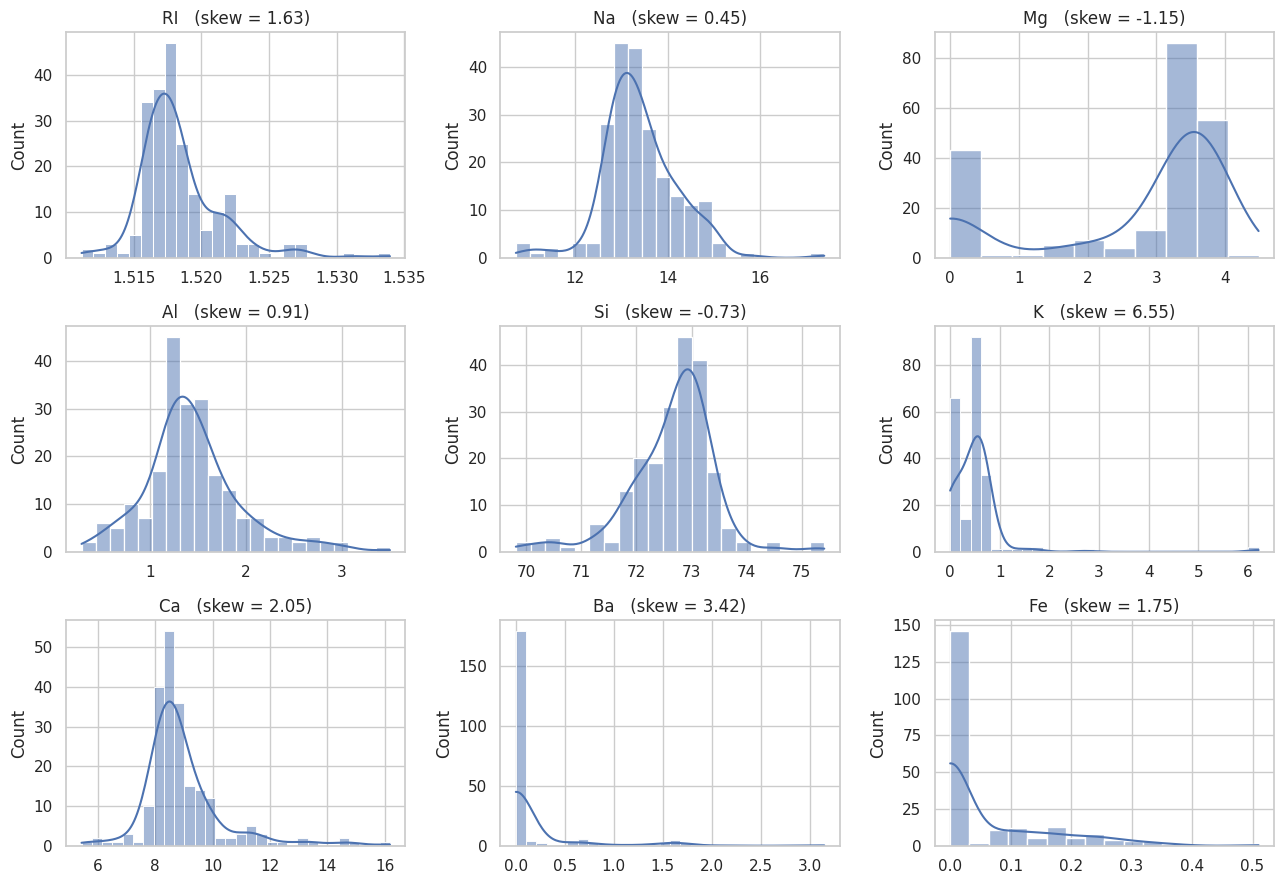

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}   (skew = {df[col].skew():.2f})")
    ax.set_xlabel("")
plt.tight_layout(); plt.show()

In [8]:
df[FEATURES].skew().sort_values(ascending=False).to_frame("skewness").T

,K,Ba,Ca,Fe,RI,Al,Na,Si,Mg
skewness,6.552,3.416,2.047,1.754,1.625,0.907,0.454,-0.73,-1.153


> **Key insight — distributions**
> * **K** (skew 6.5), **Ba** (3.4), **Ca** (2.1), **Fe** (1.8) and **RI** (1.6) are strongly right-skewed. Mg is left-skewed with a big spike at 0.
>   Na and Si are roughly bell-shaped.
> * The features live on very different scales (RI ≈ 1.52 vs Si ≈ 72), so **distance- and gradient-based models
>   (KNN, SVM, logistic regression) need standardisation**. Tree-based models don't care.
> * Because scaling must be fitted on the training data only, we will put it **inside a Pipeline** to avoid data leakage.

## 5. Which features separate the classes?

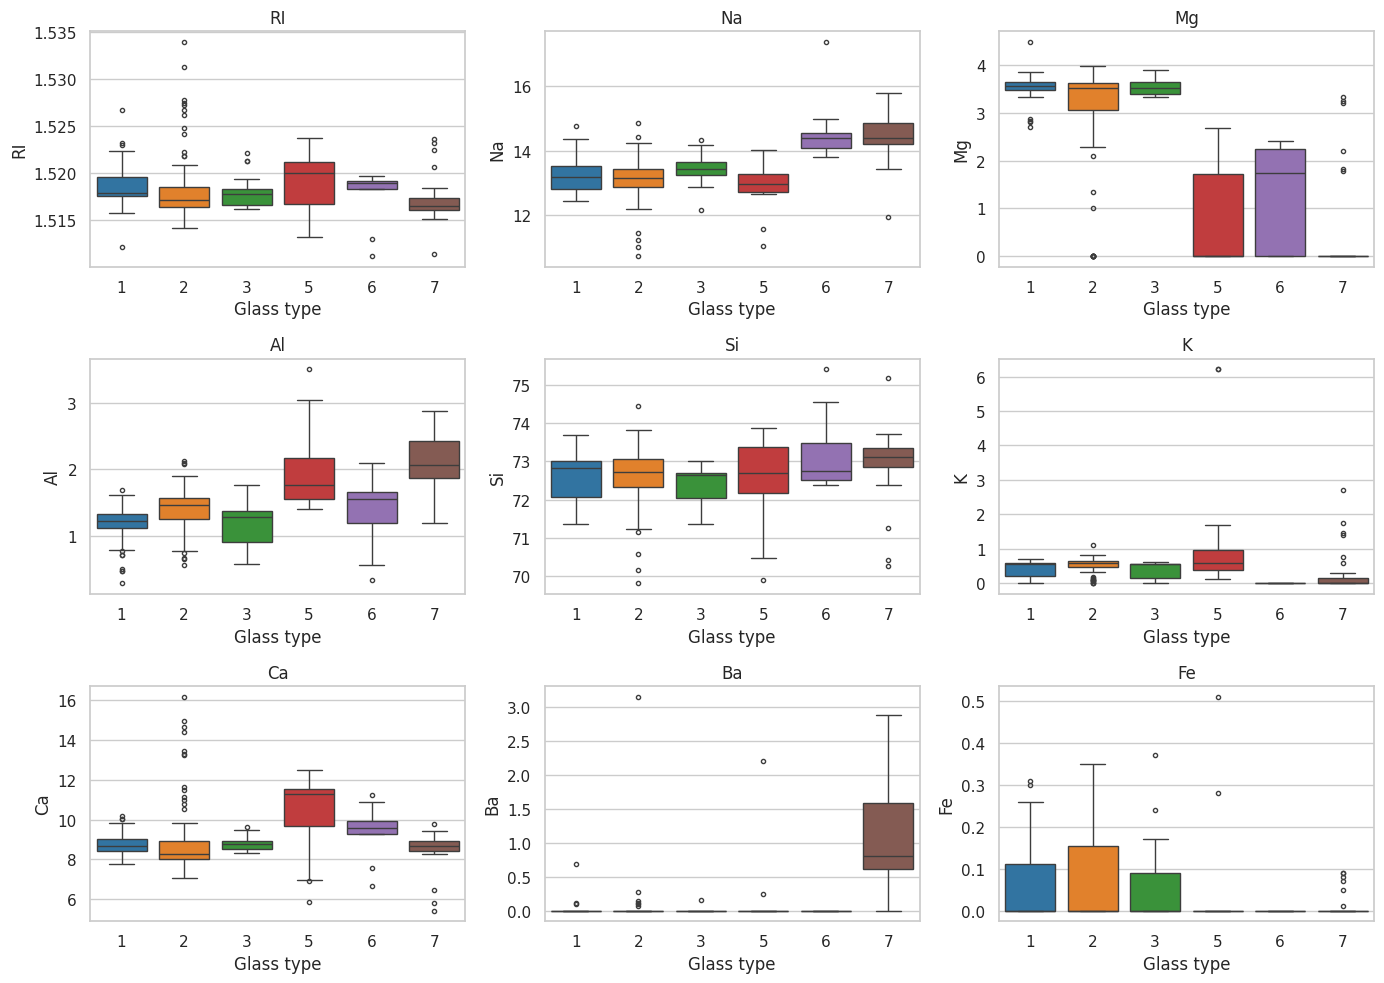

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette=PALETTE, legend=False, ax=ax, fliersize=3)
    ax.set_xlabel("Glass type"); ax.set_title(col)
plt.tight_layout(); plt.show()

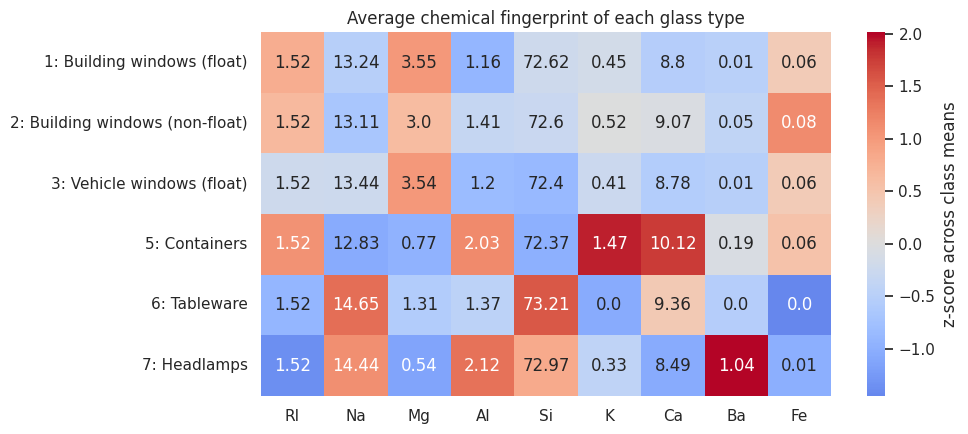

In [10]:
# Class "fingerprints": mean of each feature per class. Colour = how far a class is from the
# other classes for that feature (z-score across the 6 class means); numbers = the actual means.
means = df.groupby(TARGET)[FEATURES].mean()
z = (means - means.mean()) / means.std()
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(z.values, annot=means.round(2).astype(str).values, fmt="", cmap="coolwarm", center=0,
            xticklabels=FEATURES, yticklabels=[LABELS[c] for c in means.index],
            cbar_kws={"label": "z-score across class means"}, ax=ax)
ax.set_title("Average chemical fingerprint of each glass type"); plt.tight_layout(); plt.show()

> **Key insight — separating power**
> * **Mg** is the strongest window vs non-window signal: windows of type 1 and 3 *always* contain Mg (mean ≈ 3.5), while 23 of 29 headlamps, 7 of 13 containers and 3 of 9 tableware
>   samples have Mg = 0. **Caveat:** 9 of the 76 type-2 samples *also* have Mg = 0, which makes Mg alone imperfect.
> * **Ba** is a headlamp marker: 26 of the 29 headlamps contain Ba (mean 1.04) versus only 12 of the other 185 samples. **K** is highest in containers (1.47) and is **exactly 0 in all 9 tableware samples**.
>   **Al** is highest in headlamps and containers.
> * Types **1, 2 and 3 have almost identical chemistry** (e.g. Al 1.16 / 1.41 / 1.20). Types 1 and 3 are both *float* glass, differing in
>   how the glass is *used*, not how it is made, so composition can't tell them apart well. Expect these classes to be confused with each other.

## 6. Correlations between features

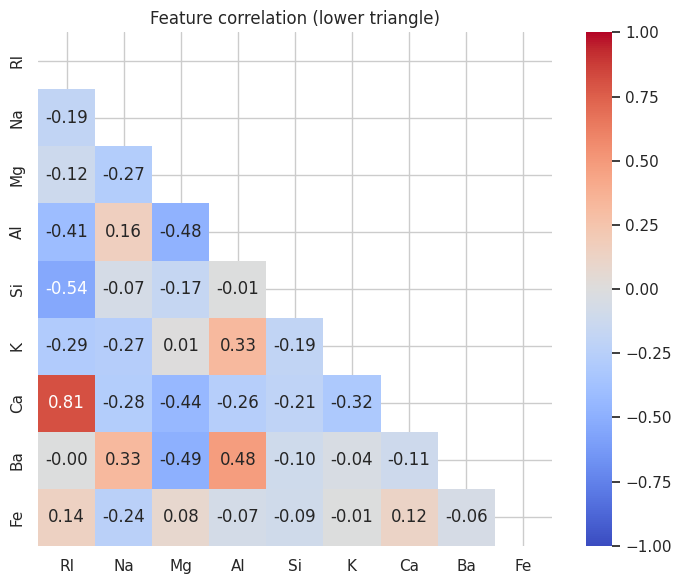

,,r
Ca,RI,0.810
Si,RI,-0.542
Ba,Mg,-0.492
Al,Mg,-0.482
Ba,Al,0.479
Ca,Mg,-0.444


In [11]:
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title("Feature correlation (lower triangle)"); plt.tight_layout(); plt.show()

pairs = (corr.where(~mask).stack().rename("r").to_frame()
         .assign(abs_r=lambda d: d["r"].abs()).sort_values("abs_r", ascending=False).head(6)[["r"]])
pairs

> **Key insight — correlations**
> * The strongest link is **RI ↔ Ca (r = 0.81)**, which makes physical sense: refractive index is a *consequence* of composition. RI is also negatively correlated with Si (−0.54).
> * Mg is negatively correlated with Ba (−0.49) and Al (−0.48).
> * Nothing is so redundant (|r| > 0.9) that a feature should be dropped. Tree ensembles are unaffected by correlation; for logistic regression
>   the coefficients of RI and Ca will be harder to interpret individually.

## 7. Class overlap: pairplot and PCA

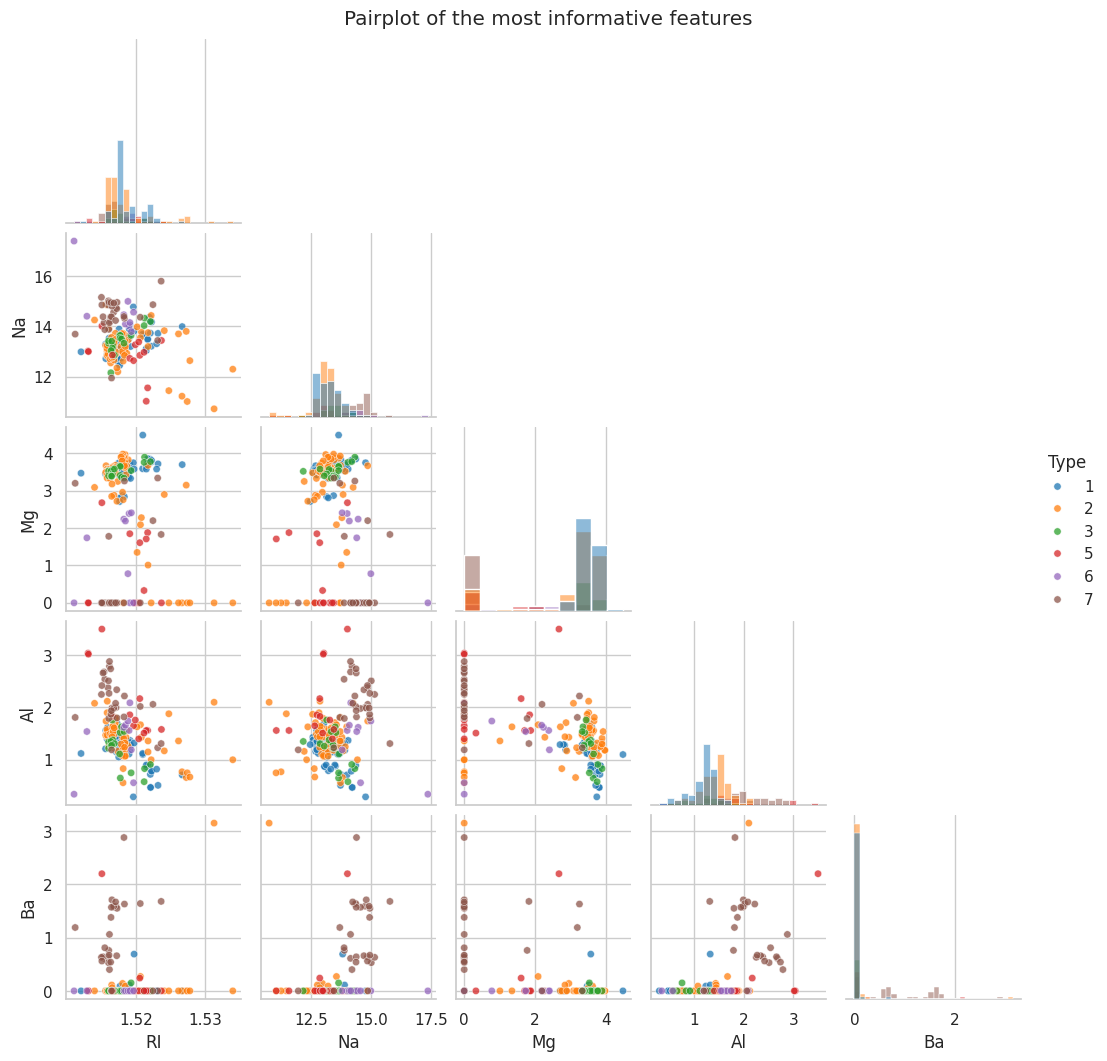

In [12]:
plot_df = df.assign(Type=df[TARGET].astype(str))
order = [str(c) for c in sorted(CLASS_NAMES)]
g = sns.pairplot(plot_df, vars=["RI", "Na", "Mg", "Al", "Ba"], hue="Type", hue_order=order,
                 palette={str(k): v for k, v in PALETTE.items()}, corner=True, diag_kind="hist",
                 plot_kws=dict(alpha=0.75, s=28), height=2.1)
g.figure.suptitle("Pairplot of the most informative features", y=1.01)
plt.show()

Variance explained by PC1, PC2: [0.279 0.228] | total: 0.507


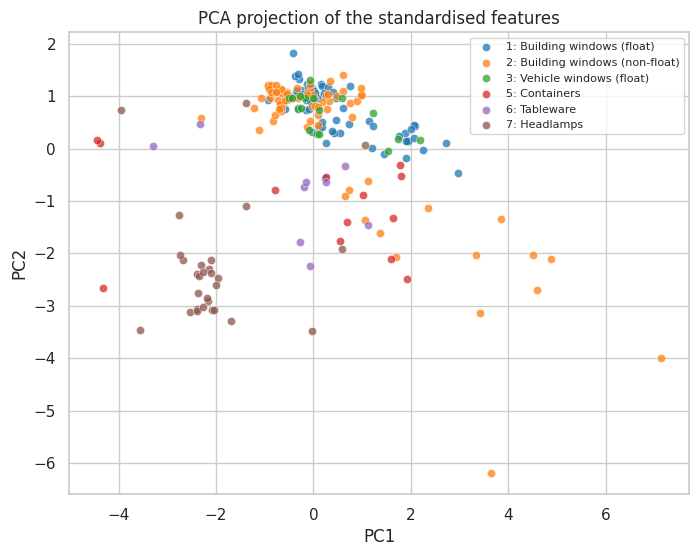

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# (Scaling on the full data is fine here: this is only a visualisation, not a model evaluation.)
Z = StandardScaler().fit_transform(df[FEATURES])
pca = PCA(n_components=2).fit(Z)
P = pca.transform(Z)
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_.round(3),
      "| total:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(CLASS_NAMES):
    m = (df[TARGET] == c).to_numpy()
    ax.scatter(P[m, 0], P[m, 1], label=LABELS[c], color=PALETTE[c], alpha=0.75, s=35, edgecolor="white", linewidth=0.4)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=8, loc="best")
ax.set_title("PCA projection of the standardised features"); plt.show()

> **Key insight — class overlap**
> * In the pairplot and the PCA view, types **1, 2 and 3 pile up in a single dense blob**. No pair of features pulls them apart. This is where most model errors will come from.
> * **Headlamps (7)** form a fairly distinct cluster (high Ba, high Al, Mg near 0), and containers (5) and tableware (6) sit in a sparser region away from the window blob,
>   but with few samples each and some intermixing.
> * The stray orange (type 2) points far from the blob are the type-2 samples with Mg = 0 and unusual RI. They look chemically unlike other building glass.
> * The two principal components explain only ~51% of the variance, so a 2D picture hides a lot. The overlap is real, but a model using all 9 features may do better than this plot suggests.

## 8. Outliers: remove or keep?

In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    return (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)

out = df[FEATURES].apply(iqr_outliers)
summary = pd.DataFrame({"n_outliers": out.sum(), "pct_of_rows": (100 * out.mean()).round(1)})
display(summary.T)

print("Which glass types do the outliers belong to?")
for col in ["RI", "Ca", "K", "Ba", "Fe"]:
    print(f"  {col:>2}: {df.loc[out[col], TARGET].value_counts().sort_index().to_dict()}")
print(f"\nRows that are an outlier in at least one feature: {out.any(axis=1).sum()} of {len(df)}")

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
n_outliers,17.0,7.0,0.0,18.0,12.0,7.0,26.0,38.0,12.0
pct_of_rows,7.9,3.3,0.0,8.4,5.6,3.3,12.1,17.8,5.6


Which glass types do the outliers belong to?
  RI: {1: 3, 2: 9, 5: 1, 6: 1, 7: 3}
  Ca: {2: 12, 5: 8, 6: 3, 7: 3}
   K: {5: 3, 7: 4}
  Ba: {1: 3, 2: 6, 3: 1, 5: 2, 7: 26}
  Fe: {1: 3, 2: 6, 3: 1, 5: 2}

Rows that are an outlier in at least one feature: 78 of 214


> **Key insight — outliers**
> * By the 1.5×IQR rule, **78 of 214 rows (36%)** are an outlier in at least one feature. Deleting them would throw away over a third of an already tiny dataset.
> * The "outliers" are mostly **class-specific signal, not errors**: 26 of the 38 Ba "outliers" are headlamps (Ba is zero for most samples, so the IQR is 0 and *any* Ba is flagged), and all K outliers belong to
>   containers or headlamps. Ca outliers occur in types 2, 5, 6, 7.
> * **Decision: keep every row.** Tree ensembles are robust to outliers, and scaling/log-transforms handle the rest.
> * In a forensic setting, an unusual composition is exactly the kind of evidence that distinguishes one source of glass from another.

## 9. Feature-engineering ideas (previewed here, tested in the modeling notebook)

Domain knowledge suggests a few derived features: **Ca/Na** and **Mg/Al** ratios, a **Ba-present** flag (Ba is mostly 0), a **Mg-is-zero** flag,
and `log1p` of the skewed oxides. Do the ratios look useful?

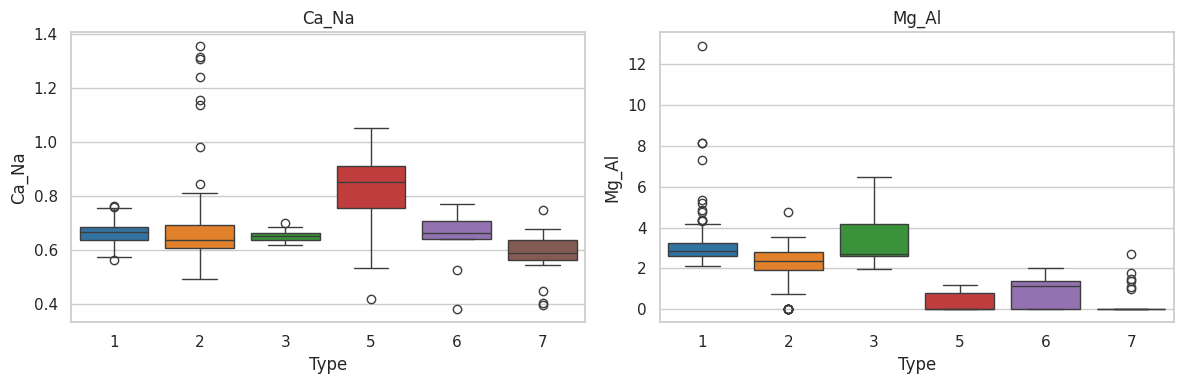

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Ca_Na,Mg_Al,Ba_present,Mg_zero
0,1.521,13.64,1.703,1.10,71.78,0.058,8.75,0.0,0.0,0.641,4.082,0,0
1,1.518,13.89,1.526,1.36,72.73,0.392,7.83,0.0,0.0,0.564,2.647,0,0
2,1.516,13.53,1.515,1.54,72.99,0.329,7.78,0.0,0.0,0.575,2.305,0,0
3,1.518,13.21,1.545,1.29,72.61,0.451,8.22,0.0,0.0,0.622,2.860,0,0
4,1.517,13.27,1.530,1.24,73.08,0.438,8.07,0.0,0.0,0.608,2.919,0,0


In [15]:
from src.preprocess import add_features

fe = add_features(df[FEATURES]).assign(Type=df[TARGET])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Ca_Na", "Mg_Al"]):
    sns.boxplot(data=fe, x="Type", y=col, hue="Type", palette=PALETTE, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()
fe.drop(columns="Type").head()

> **Key insight:** the ratios show a bit of structure but the classes still overlap. Whether they actually *improve a model* can only be
> answered by an experiment with cross-validation, which we do in notebook `02_modeling`. (Spoiler: don't assume more features = better with 213 rows.)

## 10. Summary: what EDA tells us to do next

| Finding | Decision for modeling |
|---|---|
| 1 exact duplicate row | Drop it **before** splitting (prevents train/test leakage) |
| Strong imbalance (76 vs 9 samples) | **Stratified** split and stratified K-fold; judge by **macro-F1**, not accuracy; try `class_weight="balanced"` and SMOTE |
| Only 213 rows; rare classes have 2–3 test samples | Use **repeated** cross-validation; treat any single test score as noisy |
| Skewed features on different scales | **StandardScaler inside a Pipeline** (fit on training folds only) |
| Zeros in Mg/K/Ba/Fe are real measurements | Do **not** impute them |
| Outliers are class-specific signal | **Do not remove** outliers; prefer robust tree ensembles |
| Types 1, 2, 3 have near-identical chemistry | Expect confusion between them; inspect the confusion matrix; try merging as an experiment |
| Mg, Ba, K, Al, RI carry most of the signal | Check that the model's feature importance agrees |

➡️ Next: **`02_modeling.ipynb`**